In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pyodbc
import pandas as pd

In [3]:
import pyodbc

print(pyodbc.drivers())

['SQL Server', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 17 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']


In [4]:
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=localhost;'
    'DATABASE=QuickKart_DB;'
    'Trusted_Connection=yes;'
)

In [5]:
query = "SELECT TOP 5 * FROM orders"
df = pd.read_sql(query, conn)
df

C:\Users\DELL\AppData\Local\Temp\ipykernel_15816\128191073.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,order_id,customer_id,order_date,order_time,total_order_amount,discount_amount,final_amount_paid,payment_method,order_status,repeat_purchase_flag,coupon_used,days_between_orders,customer_rating
0,ORD100000,CUST12261,2025-01-07,21:33:00,582.030029,0.0,582.030029,COD,On the way,False,False,17,1
1,ORD100001,CUST12711,2025-03-29,17:55:00,459.140015,0.0,459.140015,UPI,Delivered,True,True,1,1
2,ORD100002,CUST10207,2025-03-27,19:07:00,660.729980,0.0,660.729980,UPI,Returned,False,False,44,1
3,ORD100003,CUST11465,2025-12-21,16:48:00,362.309998,0.0,362.309998,UPI,Failed,False,True,18,4
4,ORD100004,CUST12801,2025-05-25,18:21:00,487.309998,0.0,487.309998,Card,Delivered,False,True,8,1


In [6]:
# Revenue By City

query = """
SELECT 
    c.city_name,
    ROUND(SUM(o.final_amount_paid),2) AS revenue
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
WHERE o.order_status = 'Delivered'
GROUP BY c.city_name
ORDER BY revenue DESC
"""

city_revenue = pd.read_sql(query, conn)
city_revenue

C:\Users\DELL\AppData\Local\Temp\ipykernel_15816\951076098.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  city_revenue = pd.read_sql(query, conn)


,city_name,revenue
0,Mumbai,3964036.16
1,Bangalore,2957216.49
2,Pune,1844090.32


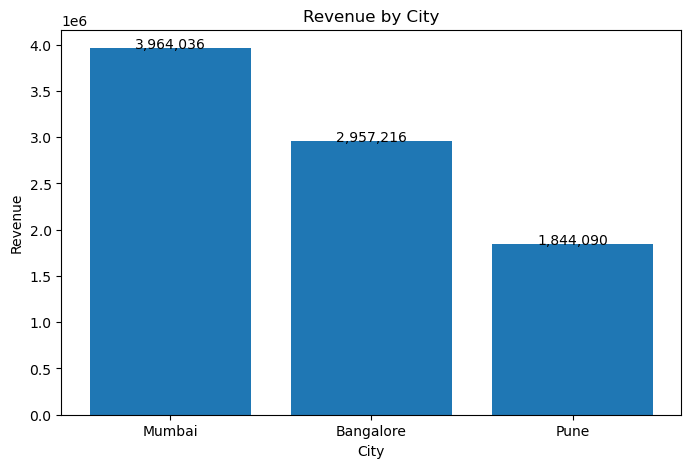

In [7]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    city_revenue['city_name'],
    city_revenue['revenue']
)

plt.xlabel('City')
plt.ylabel('Revenue')
plt.title('Revenue by City')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center'
    )

plt.show()

In [8]:
#Monthly Revenue Analysis

query = """
        SELECT
            DATENAME(MONTH, order_date) AS month_name,
            MONTH(order_date) AS month_number,
            COUNT(DISTINCT order_id) AS total_orders,
            ROUND (SUM(final_amount_paid),2) AS revenue,
            LAG (SUM(final_amount_paid))
            OVER
            (ORDER BY MONTH(order_date)) AS previous_month_revenue
        FROM orders
        WHERE order_status = 'Delivered'
        GROUP BY MONTH(order_date), DATENAME(MONTH, order_date)
        ORDER BY month_number;
"""

monthly_revenue = pd.read_sql(query,conn)
monthly_revenue

C:\Users\DELL\AppData\Local\Temp\ipykernel_15816\1928659023.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_revenue = pd.read_sql(query,conn)


,month_name,month_number,total_orders,revenue,previous_month_revenue
0,January,1,1461,745563.69,NaN
1,February,2,1268,640634.43,745563.689610
2,March,3,1469,762188.44,640634.429535
3,April,4,1430,731893.52,762188.440022
4,May,5,1442,746327.48,731893.519127
5,June,6,1341,696424.78,746327.480450
6,July,7,1424,746640.63,696424.779491
7,August,8,1495,775774.62,746640.630081
8,September,9,1460,761267.36,775774.620430
9,October,10,1415,728237.91,761267.360550


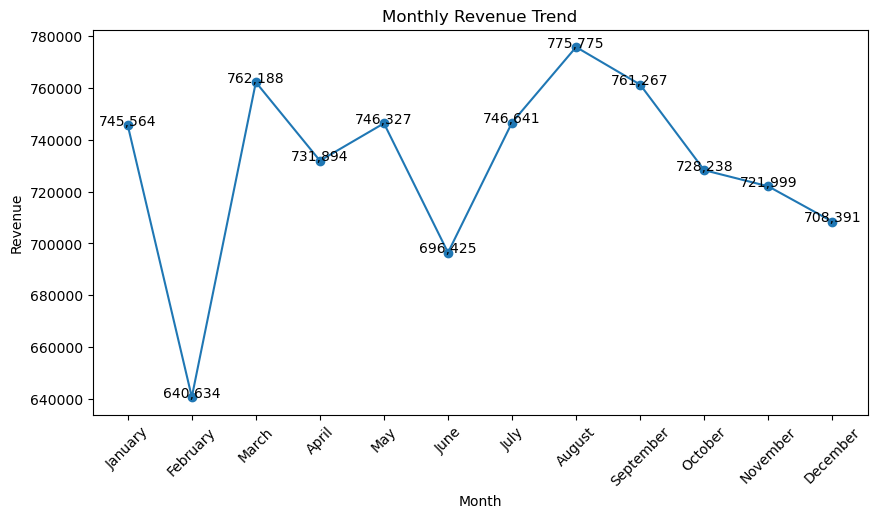

In [9]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue['month_name'],
    monthly_revenue['revenue'],
    marker='o'
)

for i, value in enumerate(monthly_revenue['revenue']):
    plt.text(
        i, value,
        f'{value:,.0f}',
        ha='center'
    )

plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend')

plt.xticks(rotation=45)

plt.show()

In [10]:
# Retention Rate by City

query = """
        SELECT
    c.city_name,
    ROUND(
        SUM(
            CASE 
                WHEN o.repeat_purchase_flag = 1
                THEN 1 ELSE 0
            END
        ) * 100.0 / COUNT(*),2
    ) AS retention_rate
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
GROUP BY c.city_name
ORDER BY retention_rate DESC;
"""

retention_city = pd.read_sql(query,conn)
retention_city

C:\Users\DELL\AppData\Local\Temp\ipykernel_15816\1615679519.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  retention_city = pd.read_sql(query,conn)


,city_name,retention_rate
0,Pune,60.63
1,Mumbai,60.06
2,Bangalore,59.81


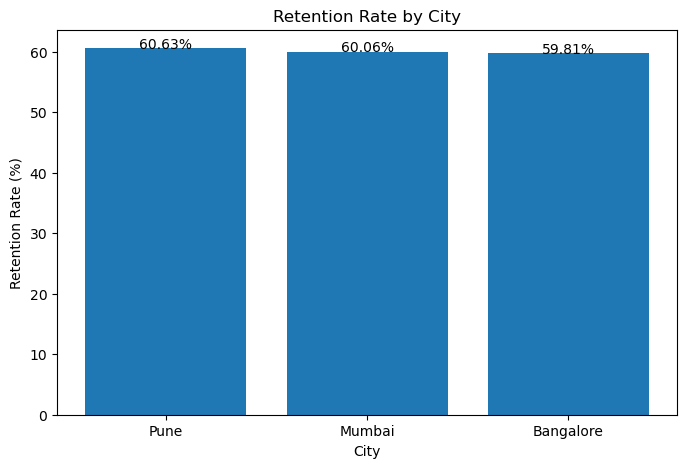

In [11]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    retention_city['city_name'],
    retention_city['retention_rate']
)

plt.xlabel('City')
plt.ylabel('Retention Rate (%)')
plt.title('Retention Rate by City')

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}%',
        ha='center'
    )

plt.show()

In [12]:
#Customer Churn Analysis

query = """
        WITH customer_orders AS
(
    SELECT
        customer_id,
        MAX(order_date) AS last_order_date
    FROM orders
    WHERE order_status = 'Delivered'
    GROUP BY customer_id
),

churn_data AS
(
    SELECT
        customer_id,
        CASE
            WHEN DATEDIFF
            ( DAY, last_order_date,
                (SELECT MAX(order_date) FROM orders)
            ) > 60 THEN 'High Risk'
            WHEN DATEDIFF
            ( DAY, last_order_date,
                (SELECT MAX(order_date) FROM orders)
            ) >= 30 THEN 'Medium Risk'

            ELSE 'Low Risk'
        END AS churn_risk
    FROM customer_orders
)

SELECT
    churn_risk,
    COUNT(*) AS customer_count,
    ROUND
    (COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(),2
    ) AS percentage
FROM churn_data
GROUP BY churn_risk
ORDER BY customer_count DESC;
"""

churn_df =  pd.read_sql(query,conn)
churn_df


C:\Users\DELL\AppData\Local\Temp\ipykernel_15816\1161278506.py:44: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  churn_df =  pd.read_sql(query,conn)


,churn_risk,customer_count,percentage
0,High Risk,1179,39.42
1,Low Risk,1072,35.84
2,Medium Risk,740,24.74


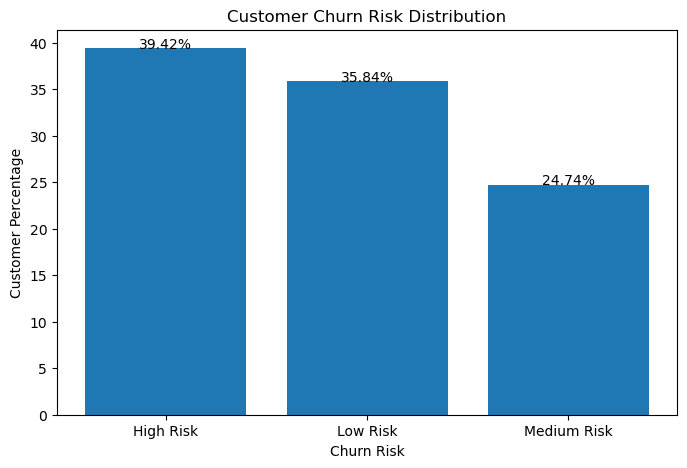

In [13]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    churn_df['churn_risk'],
    churn_df['percentage']
)

plt.xlabel('Churn Risk')
plt.ylabel('Customer Percentage')
plt.title('Customer Churn Risk Distribution')

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}%',
        ha='center'
    )

plt.show()

In [14]:
#Discount vs Repeat Purchase

query = """
SELECT
    CASE
        WHEN discount_amount <= 50
        THEN 'Low Discount'

        WHEN discount_amount <= 100
        THEN 'Medium Discount'

        ELSE 'High Discount'
    END AS discount_level,

    ROUND(
        SUM(
            CASE
                WHEN repeat_purchase_flag = 1
                THEN 1
                ELSE 0
            END
        ) * 100.0 / COUNT(*),2
    ) AS retention_rate

FROM orders

GROUP BY
    CASE
        WHEN discount_amount <= 50
        THEN 'Low Discount'

        WHEN discount_amount <= 100
        THEN 'Medium Discount'

        ELSE 'High Discount'
    END
"""

discount_df = pd.read_sql(query, conn)
discount_df

C:\Users\DELL\AppData\Local\Temp\ipykernel_15816\2580177380.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  discount_df = pd.read_sql(query, conn)


,discount_level,retention_rate
0,High Discount,60.48
1,Low Discount,60.20
2,Medium Discount,59.42


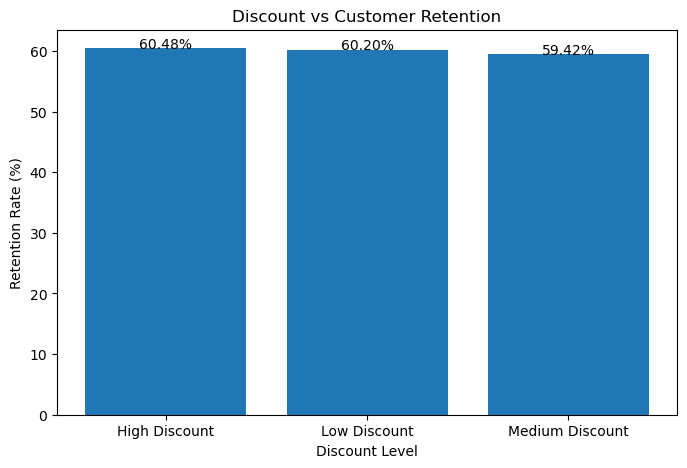

In [15]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    discount_df['discount_level'],
    discount_df['retention_rate']
)

plt.xlabel('Discount Level')
plt.ylabel('Retention Rate (%)')
plt.title('Discount vs Customer Retention')

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}%',
        ha='center'
    )

plt.show()

In [16]:
#Revenue by Segment

query = """
SELECT
    c.customer_segment,
    COUNT(DISTINCT o.customer_id) AS customers,
    COUNT(o.order_id) AS total_orders,
    ROUND(SUM(o.final_amount_paid),2) AS revenue,
    ROUND(AVG(o.final_amount_paid),2) AS avg_order_value
FROM customers c
JOIN orders o
ON c.customer_id = o.customer_id
WHERE o.order_status = 'Delivered'
GROUP BY c.customer_segment
ORDER BY revenue DESC
"""

segment_df = pd.read_sql(query, conn)
segment_df

C:\Users\DELL\AppData\Local\Temp\ipykernel_15816\1191016480.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  segment_df = pd.read_sql(query, conn)


,customer_segment,customers,total_orders,revenue,avg_order_value
0,Regular,1393,7994,4124333.54,515.93
1,Loyal,692,3851,2006811.60,521.11
2,New,624,3582,1841468.06,514.09
3,At-Risk,282,1551,792729.77,511.11


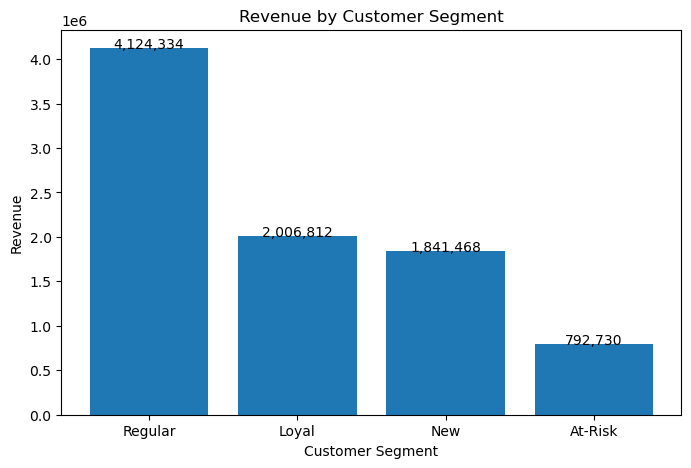

In [17]:
plt.figure(figsize=(8,5))
bars = plt.bar(
    segment_df['customer_segment'],
    segment_df['revenue']
)
plt.xlabel('Customer Segment')
plt.ylabel('Revenue')
plt.title('Revenue by Customer Segment')
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center'
    )
plt.show()

In [18]:
#Product Category Analysis

query = """
SELECT
    p.product_category,
    ROUND(SUM(
            CASE
                WHEN o.repeat_purchase_flag = 1
                THEN 1
                ELSE 0
            END
        ) * 100.0 / COUNT(*),2) AS retention_rate,
    COUNT(*) AS total_orders
FROM order_items oi
JOIN products p
ON oi.product_id = p.product_id
JOIN orders o
ON oi.order_id = o.order_id
GROUP BY p.product_category
ORDER BY retention_rate DESC
"""

category_df = pd.read_sql(query, conn)
category_df

C:\Users\DELL\AppData\Local\Temp\ipykernel_15816\1107864080.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  category_df = pd.read_sql(query, conn)


,product_category,retention_rate,total_orders
0,Bakery,61.43,6165
1,Household,61.01,6212
2,Personal Care,60.77,6326
3,Dairy,60.27,6350
4,Frozen Foods,59.94,6158
5,Snacks,59.37,6227
6,Beverages,59.24,6101
7,Fruits & Vegetables,58.77,6161


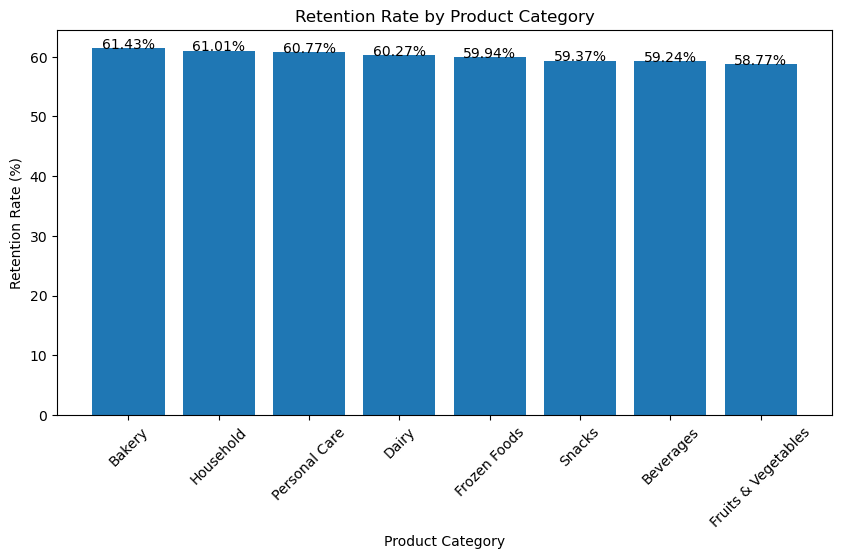

In [19]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    category_df['product_category'],
    category_df['retention_rate']
)

plt.xlabel('Product Category')
plt.ylabel('Retention Rate (%)')
plt.title('Retention Rate by Product Category')

plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}%',
        ha='center'
    )

plt.show()

In [20]:
#Correlation Heatmap

query = """
SELECT
    total_order_amount,
    discount_amount,
    final_amount_paid,
    quantity,
    delivery_time_minutes,
    promised_delivery_time,
    customer_rating,
    repeat_purchase_flag,
    days_between_orders
FROM orders o
JOIN order_items oi
ON o.order_id = oi.order_id
JOIN delivery d
ON o.order_id = d.order_id
"""

corr_df = pd.read_sql(query, conn)
corr_df.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_15816\3691256650.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  corr_df = pd.read_sql(query, conn)


,total_order_amount,discount_amount,final_amount_paid,quantity,delivery_time_minutes,promised_delivery_time,customer_rating,repeat_purchase_flag,days_between_orders
0,582.030029,0.0,582.030029,1,26,29,1,False,17
1,459.140015,0.0,459.140015,1,19,20,1,True,1
2,459.140015,0.0,459.140015,3,19,20,1,True,1
3,660.729980,0.0,660.729980,3,34,29,1,False,44
4,660.729980,0.0,660.729980,4,34,29,1,False,44


In [21]:
correlation_matrix = corr_df.corr()
correlation_matrix

,total_order_amount,discount_amount,final_amount_paid,quantity,delivery_time_minutes,promised_delivery_time,customer_rating,repeat_purchase_flag,days_between_orders
total_order_amount,1.000000,0.305961,0.939930,-0.000217,-0.009780,-0.015972,-0.012556,0.016929,-0.008930
discount_amount,0.305961,1.000000,-0.037416,-0.002099,-0.011229,-0.017733,0.001597,0.001879,-0.003651
final_amount_paid,0.939930,-0.037416,1.000000,0.000525,-0.006239,-0.010406,-0.013752,0.017096,-0.008064
quantity,-0.000217,-0.002099,0.000525,1.000000,0.001223,-0.003464,0.003118,-0.002815,-0.007033
delivery_time_minutes,-0.009780,-0.011229,-0.006239,0.001223,1.000000,0.540925,-0.004239,-0.014806,-0.004894
promised_delivery_time,-0.015972,-0.017733,-0.010406,-0.003464,0.540925,1.000000,0.002647,0.000303,0.002153
customer_rating,-0.012556,0.001597,-0.013752,0.003118,-0.004239,0.002647,1.000000,0.014862,-0.005840
repeat_purchase_flag,0.016929,0.001879,0.017096,-0.002815,-0.014806,0.000303,0.014862,1.000000,-0.002956
days_between_orders,-0.008930,-0.003651,-0.008064,-0.007033,-0.004894,0.002153,-0.005840,-0.002956,1.000000


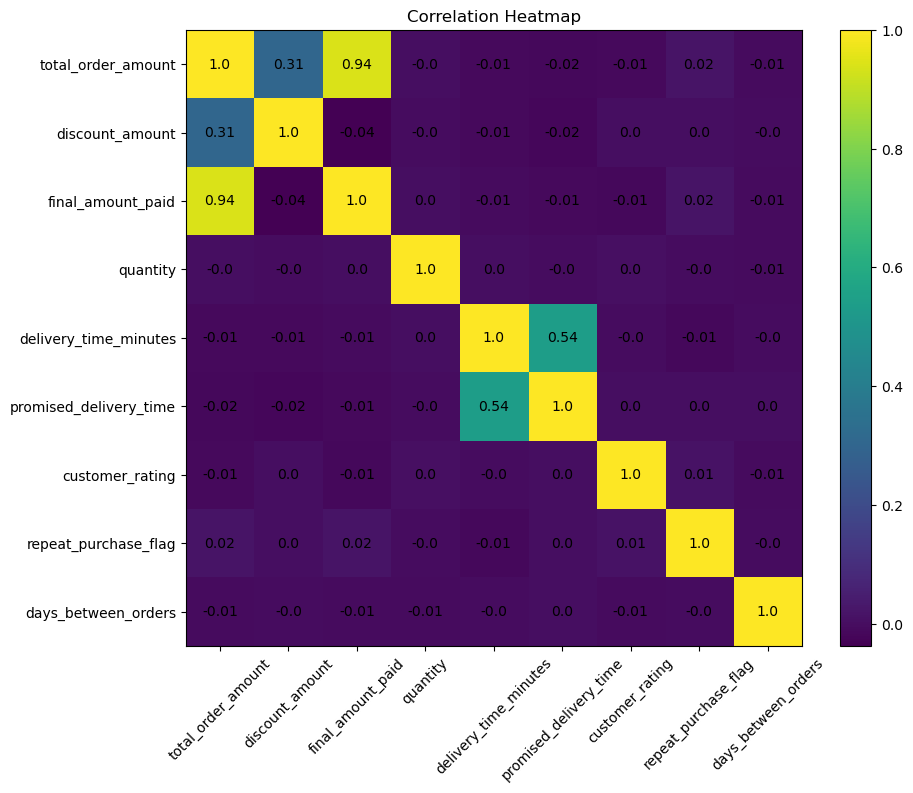

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            round(correlation_matrix.iloc[i, j], 2),
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap')

plt.show()

In [23]:
#Customer Rating Distribution Analysis

query = """
SELECT
    customer_rating,
    COUNT(*) AS total_orders
FROM orders
GROUP BY customer_rating
ORDER BY customer_rating
"""

rating_df = pd.read_sql(query, conn)
rating_df

C:\Users\DELL\AppData\Local\Temp\ipykernel_15816\4029565254.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rating_df = pd.read_sql(query, conn)


,customer_rating,total_orders
0,1,4191
1,2,3899
2,3,3936
3,4,3904
4,5,4070


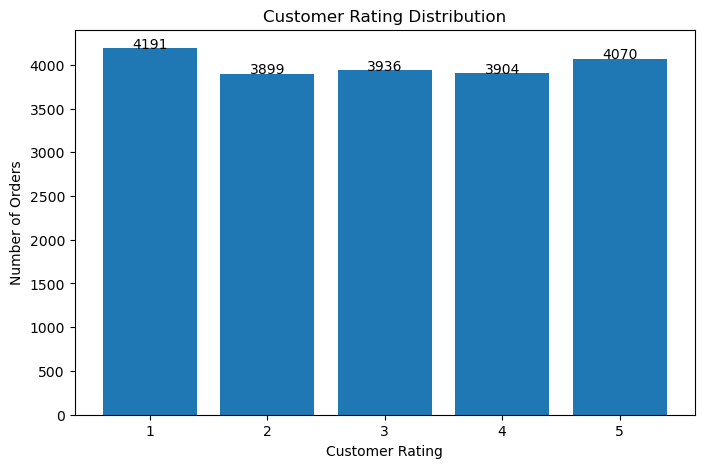

In [24]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    rating_df['customer_rating'],
    rating_df['total_orders']
)

plt.xlabel('Customer Rating')
plt.ylabel('Number of Orders')
plt.title('Customer Rating Distribution')

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center'
    )

plt.show()

In [25]:
#Churn Risk by Customer Segment

query = """
WITH customer_orders AS
(
    SELECT
        customer_id,
        MAX(order_date) AS last_order_date
    FROM orders
    WHERE order_status = 'Delivered'
    GROUP BY customer_id
),

churn_data AS
(
    SELECT
        customer_id,
        CASE
            WHEN DATEDIFF( DAY, last_order_date,
                (SELECT MAX(order_date) FROM orders)) > 60 THEN 'High Risk'

            WHEN DATEDIFF( DAY, last_order_date,
                (SELECT MAX(order_date) FROM orders)) >= 30 THEN 'Medium Risk'

            ELSE 'Low Risk'
        END AS churn_risk
    FROM customer_orders
)

SELECT
    c.customer_segment, cd.churn_risk,
    COUNT(DISTINCT c.customer_id) AS customers
FROM customers c
JOIN churn_data cd
ON c.customer_id = cd.customer_id
GROUP BY
    c.customer_segment,
    cd.churn_risk
"""

segment_churn_df = pd.read_sql(query, conn)
segment_churn_df.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_15816\469399963.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  segment_churn_df = pd.read_sql(query, conn)


,customer_segment,churn_risk,customers
0,At-Risk,High Risk,120
1,Loyal,High Risk,272
2,New,High Risk,232
3,Regular,High Risk,555
4,At-Risk,Low Risk,99


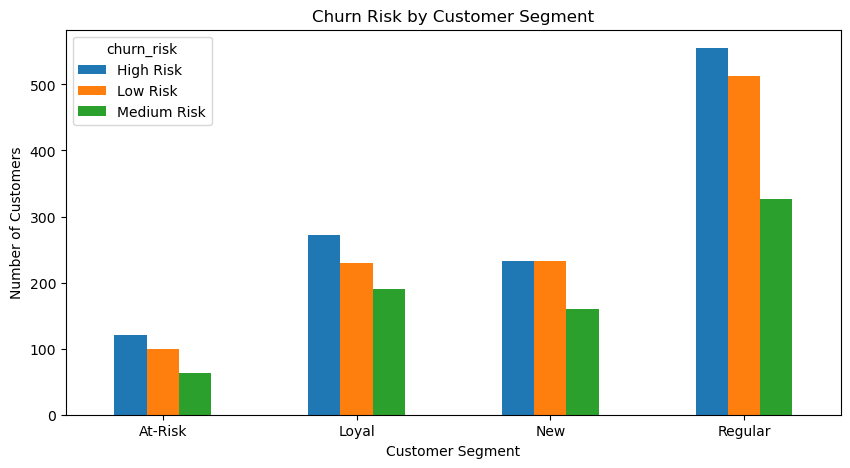

In [26]:
pivot_df = segment_churn_df.pivot(
    index='customer_segment',
    columns='churn_risk',
    values='customers'
)

pivot_df.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Churn Risk by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

In [27]:
#Delivery Experience vs Customer Rating

query = """
SELECT 
	d.delivery_status,
	ROUND(
		AVG(o.customer_rating * 1.0),2
	) AS avg_rating,
	COUNT(*) as total_orders
FROM delivery as d
JOIN orders as o
ON d.order_id = o.order_id
GROUP BY d.delivery_status
ORDER BY avg_rating DESC;

"""

delivery_rating_df = pd.read_sql(query,conn)
delivery_rating_df

C:\Users\DELL\AppData\Local\Temp\ipykernel_15816\3734224289.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  delivery_rating_df = pd.read_sql(query,conn)


,delivery_status,avg_rating,total_orders
0,On-Time,3.00,6242
1,Early,2.99,5392
2,Delayed,2.98,8366


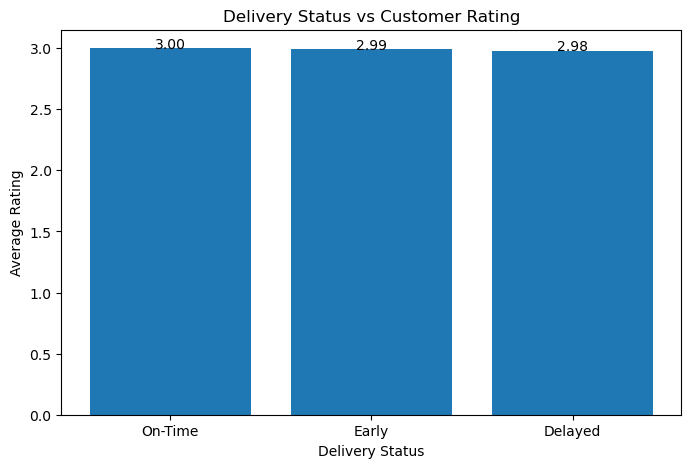

In [28]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    delivery_rating_df['delivery_status'],
    delivery_rating_df['avg_rating']
)

plt.xlabel('Delivery Status')
plt.ylabel('Average Rating')
plt.title('Delivery Status vs Customer Rating')

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center'
    )

plt.show()

In [29]:
query = """
SELECT
    CASE
        WHEN discount_amount <= 50 THEN 'Low Discount'
        WHEN discount_amount <= 100 THEN 'Medium Discount'
        ELSE 'High Discount'
    END AS discount_level,
    ROUND( AVG(total_order_amount),2) AS avg_order_value,
    COUNT(*) AS total_orders
FROM orders
GROUP BY
    CASE
        WHEN discount_amount <= 50 THEN 'Low Discount'
        WHEN discount_amount <= 100 THEN 'Medium Discount'
        ELSE 'High Discount'
    END
"""

discount_spending_df = pd.read_sql(query, conn)

discount_spending_df

C:\Users\DELL\AppData\Local\Temp\ipykernel_15816\2573057760.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  discount_spending_df = pd.read_sql(query, conn)


,discount_level,avg_order_value,total_orders
0,High Discount,672.65,5379
1,Low Discount,541.16,10400
2,Medium Discount,539.00,4221


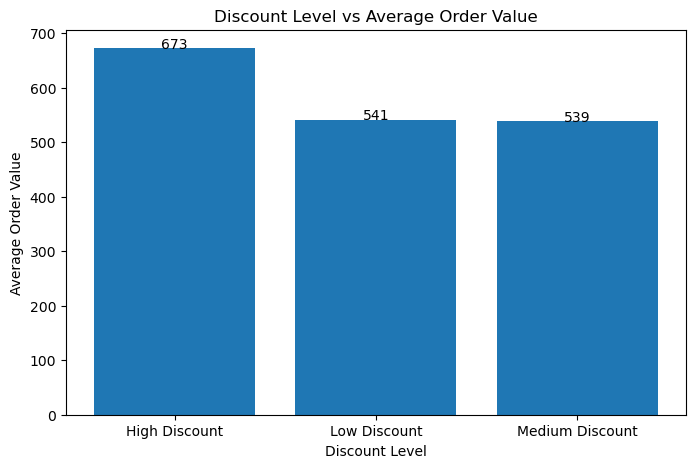

In [30]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    discount_spending_df['discount_level'],
    discount_spending_df['avg_order_value']
)

plt.xlabel('Discount Level')
plt.ylabel('Average Order Value')
plt.title('Discount Level vs Average Order Value')

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center'
    )

plt.show()

In [33]:
# Customer analysis

query = """
WITH customer_metrics AS
(
    SELECT
        customer_id, COUNT(order_id) AS total_orders,
        ROUND(SUM(final_amount_paid),2) AS total_spent,
        ROUND(AVG(final_amount_paid),2) AS avg_order_value
    FROM orders
    WHERE order_status = 'Delivered'
    GROUP BY customer_id
)

SELECT
    CASE
        WHEN total_spent >= 5000 THEN 'High Value'
        WHEN total_spent >= 2500 THEN 'Medium Value'
        ELSE 'Low Value'
    END AS customer_type,
    COUNT(*) AS customers,
    ROUND(AVG(total_orders),2) AS avg_orders,
    ROUND(AVG(total_spent),2) AS avg_spending
FROM customer_metrics
GROUP BY
    CASE
        WHEN total_spent >= 5000 THEN 'High Value'
        WHEN total_spent >= 2500 THEN 'Medium Value'
        ELSE 'Low Value'
    END 
"""

high_value_df = pd.read_sql(query, conn)

high_value_df

C:\Users\DELL\AppData\Local\Temp\ipykernel_15816\411779736.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  high_value_df = pd.read_sql(query, conn)


,customer_type,customers,avg_orders,avg_spending
0,Low Value,1221,3,1699.53
1,Medium Value,1559,6,3500.67
2,High Value,211,10,5841.99


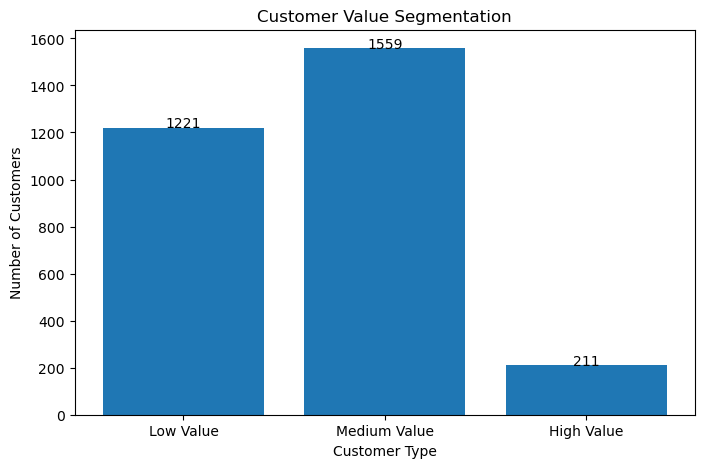

In [34]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    high_value_df['customer_type'],
    high_value_df['customers']
)

plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.title('Customer Value Segmentation')

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center'
    )

plt.show()

In [35]:
#Rating and purchase pattern

query = """
SELECT 
    customer_rating,
    ROUND(AVG(
            CAST(repeat_purchase_flag AS FLOAT)) * 100,2)
    AS repeat_purchase_rate,
    COUNT(*) AS total_orders
FROM orders
GROUP BY customer_rating
ORDER BY customer_rating
"""

rating_repeat_df = pd.read_sql(query,conn)
rating_repeat_df


C:\Users\DELL\AppData\Local\Temp\ipykernel_15816\2227982085.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rating_repeat_df = pd.read_sql(query,conn)


,customer_rating,repeat_purchase_rate,total_orders
0,1,59.84,4191
1,2,59.19,3899
2,3,60.82,3936
3,4,60.04,3904
4,5,60.64,4070


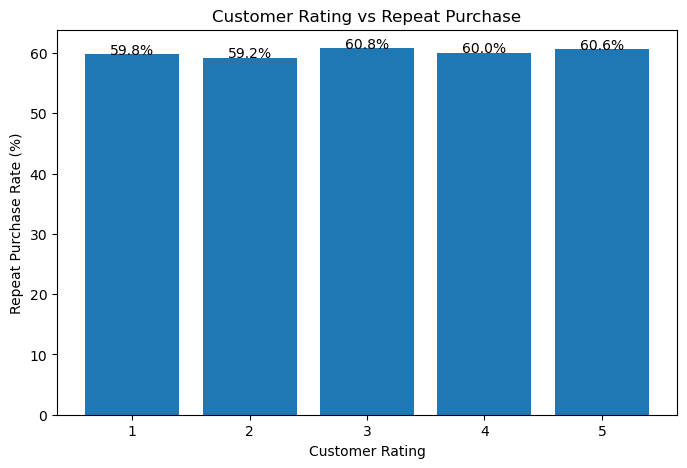

In [36]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    rating_repeat_df['customer_rating'],
    rating_repeat_df['repeat_purchase_rate']
)

plt.xlabel('Customer Rating')
plt.ylabel('Repeat Purchase Rate (%)')
plt.title('Customer Rating vs Repeat Purchase')

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center'
    )

plt.show()

In [38]:
#Customer Purchase Behavior by City

query = """
SELECT 
    c.city_name,
    COUNT(o.order_id) AS total_orders,
    ROUND(SUM(o.final_amount_paid),2) AS revenue,
    ROUND(AVG(o.final_amount_paid),2) AS avg_order_value
FROM customers c
JOIN orders o
ON c.customer_id = o.customer_id
WHERE o.order_status = 'Delivered'
GROUP BY c.city_name
ORDER BY revenue DESC
"""

city_behavior_df = pd.read_sql(query, conn)
city_behavior_df

C:\Users\DELL\AppData\Local\Temp\ipykernel_15816\1109688427.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  city_behavior_df = pd.read_sql(query, conn)


,city_name,total_orders,revenue,avg_order_value
0,Mumbai,6824,3964036.16,580.90
1,Bangalore,6003,2957216.49,492.62
2,Pune,4151,1844090.32,444.25


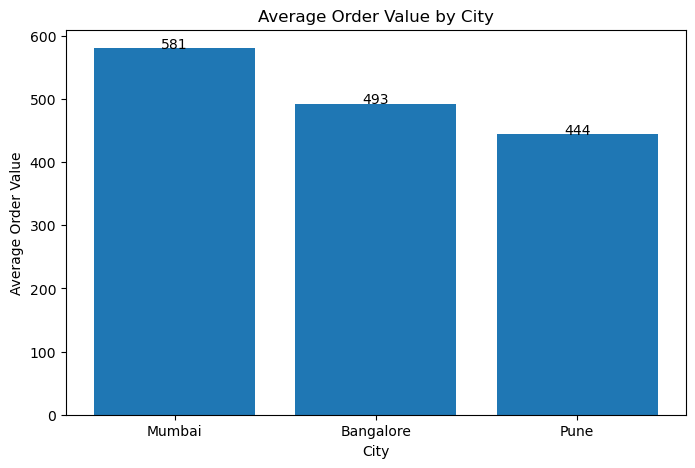

In [39]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    city_behavior_df['city_name'],
    city_behavior_df['avg_order_value']
)

plt.xlabel('City')
plt.ylabel('Average Order Value')
plt.title('Average Order Value by City')

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center'
    )

plt.show()